# Intro to Pandas
The Pandas library is more complex than numpy and works more with complex, structured, tabular data. Think Spreadsheet manipulation vs numpys more general rows and columns. In general, Numpy is used for more mathematical operations and arrays, while pandas is used for data analysis and is another standard library in geosciences. 

Where Numpy has arrays, Pandas has dataframes.

In [1]:
import numpy as np
import pandas as pd

#let's compare numpy to pandas. to do this, let's make up some CTD data
arr = np.array([[1, 10, 25],
                [5, 8, 20],
                [10, 7.5, 23]]) #this dataset has depth in first column, temp in second column, and salinity in third column
arr

array([[ 1. , 10. , 25. ],
       [ 5. ,  8. , 20. ],
       [10. ,  7.5, 23. ]])

In [2]:
#not bad, but what would this look like in pandas?
data = {'depth': [1, 5, 10],'temp': [10, 8, 7.5],'salinity': [10, 7.5, 23]}
df = pd.DataFrame(data) #alot more clean and easier to read
df

,depth,temp,salinity
0,1,10.0,10.0
1,5,8.0,7.5
2,10,7.5,23.0


In [3]:
#99% of the time, you're not making your own dataframe but instead loading it in. Let's load in a csv file through ERDDAP as an example
df = pd.read_csv('https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_918182_v1.csv?time%2Cdepth%2CTemperature&time%3E=2015-07-24T08%3A00%3A00Z&time%3C=2015-07-25&depth%3E=0')
df

,time,depth,Temperature
0,UTC,m,degrees Celsius
1,2015-07-24T08:00:00Z,0.781,22.4344
2,2015-07-24T09:00:00Z,0.664,NaN
3,2015-07-24T10:00:00Z,0.533,22.4355
4,2015-07-24T11:00:00Z,0.507,22.3712
5,2015-07-24T12:00:00Z,0.534,22.272
6,2015-07-24T13:00:00Z,0.686,22.0909
7,2015-07-24T14:00:00Z,0.891,22.0754
8,2015-07-24T15:00:00Z,1.06,22.061
9,2015-07-24T16:00:00Z,1.196,22.0346


In [4]:
#you can find the length of the dataframe using len
len(df)

18

In [5]:
#you can use .info to get information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   time         18 non-null     object
 1   depth        18 non-null     object
 2   Temperature  16 non-null     object
dtypes: object(3)
memory usage: 564.0+ bytes


In [6]:
#if you want the index to be a specific column instead of just integers, you can tell it to be
df = pd.read_csv('https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_918182_v1.csv?time%2Cdepth%2CTemperature&time%3E=2015-07-24T08%3A00%3A00Z&time%3C=2015-07-25&depth%3E=0',
                 index_col=["time"])
df

,depth,Temperature
time,,
UTC,m,degrees Celsius
2015-07-24T08:00:00Z,0.781,22.4344
2015-07-24T09:00:00Z,0.664,NaN
2015-07-24T10:00:00Z,0.533,22.4355
2015-07-24T11:00:00Z,0.507,22.3712
2015-07-24T12:00:00Z,0.534,22.272
2015-07-24T13:00:00Z,0.686,22.0909
2015-07-24T14:00:00Z,0.891,22.0754
2015-07-24T15:00:00Z,1.06,22.061


In [7]:
df.shape

(18, 2)

In [8]:
df.columns

Index(['depth', 'Temperature'], dtype='object')

In [10]:
#We can also change column names
df = df.rename(columns = {'Temperature': 'temp (C)'})
df = df.dropna(subset=['temp (C)']) #drop any NAs in specific columns
df

,depth,temp (C)
time,,
UTC,m,degrees Celsius
2015-07-24T08:00:00Z,0.781,22.4344
2015-07-24T10:00:00Z,0.533,22.4355
2015-07-24T11:00:00Z,0.507,22.3712
2015-07-24T12:00:00Z,0.534,22.272
2015-07-24T13:00:00Z,0.686,22.0909
2015-07-24T14:00:00Z,0.891,22.0754
2015-07-24T15:00:00Z,1.06,22.061
2015-07-24T16:00:00Z,1.196,22.0346


In [11]:
#say you want to just look at 1 column, there's two ways of calling a pandas column
df.depth
df['depth']

time
UTC                         m
2015-07-24T08:00:00Z    0.781
2015-07-24T10:00:00Z    0.533
2015-07-24T11:00:00Z    0.507
2015-07-24T12:00:00Z    0.534
2015-07-24T13:00:00Z    0.686
2015-07-24T14:00:00Z    0.891
2015-07-24T15:00:00Z     1.06
2015-07-24T16:00:00Z    1.196
2015-07-24T17:00:00Z    1.245
2015-07-24T18:00:00Z    1.175
2015-07-24T19:00:00Z    0.931
2015-07-24T20:00:00Z    0.672
2015-07-24T21:00:00Z    0.436
2015-07-24T23:00:00Z    0.326
2015-07-25T00:00:00Z    0.296
Name: depth, dtype: object

In [12]:
#If you have a huge dataframe and just want to look at the first few rows, u can use .head()
df.head()

,depth,temp (C)
time,,
UTC,m,degrees Celsius
2015-07-24T08:00:00Z,0.781,22.4344
2015-07-24T10:00:00Z,0.533,22.4355
2015-07-24T11:00:00Z,0.507,22.3712
2015-07-24T12:00:00Z,0.534,22.272


<Axes: xlabel='time'>

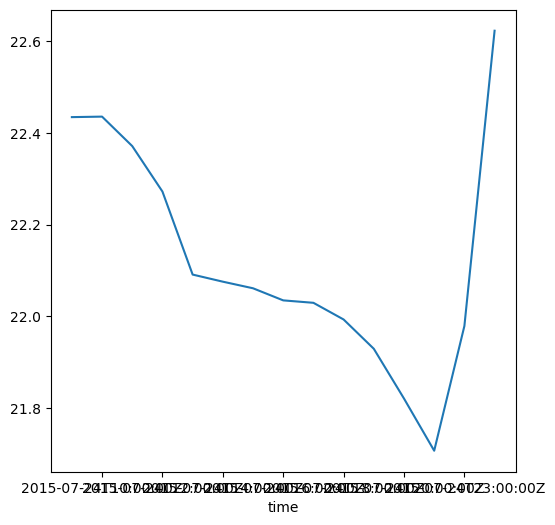

In [13]:
#Currently, the temp column is data type object. So we need to change it to datatype float or int so that we can plot
df['temp (C)'] = pd.to_numeric(df['temp (C)'], errors='coerce')
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')

df['temp (C)'].plot(figsize=(6,6))

In [14]:
#we can do some math on dataframes too
df['depth'].mean()

0.7512666666666667

In [15]:
#get a list of unique values in column
df.depth.unique()

array([  nan, 0.781, 0.533, 0.507, 0.534, 0.686, 0.891, 1.06 , 1.196,
       1.245, 1.175, 0.931, 0.672, 0.436, 0.326, 0.296])

In [16]:
#we can also use conditionals on dataframes
df2 = df[df['temp (C)']>22]
df2

,depth,temp (C)
time,,
2015-07-24T08:00:00Z,0.781,22.4344
2015-07-24T10:00:00Z,0.533,22.4355
2015-07-24T11:00:00Z,0.507,22.3712
2015-07-24T12:00:00Z,0.534,22.2720
2015-07-24T13:00:00Z,0.686,22.0909
2015-07-24T14:00:00Z,0.891,22.0754
2015-07-24T15:00:00Z,1.060,22.0610
2015-07-24T16:00:00Z,1.196,22.0346
2015-07-24T17:00:00Z,1.245,22.0293


In [18]:
#we can also add a column to the dataframe
df['salinity'] = np.random.uniform(low=20, high=30, size=16)
df = df.reset_index() #if you want to revert the dataframe back to normal index, just reset the index
# Remove the first row to get rid of these units in the dataframe. usually a dataframe is just the entries
df = df.iloc[1:]
df['time'] = pd.to_datetime(df['time'], errors='coerce')

df

,time,depth,temp (C),salinity
1,2015-07-24 08:00:00+00:00,0.781,22.4344,27.573734
2,2015-07-24 10:00:00+00:00,0.533,22.4355,26.843212
3,2015-07-24 11:00:00+00:00,0.507,22.3712,27.625355
4,2015-07-24 12:00:00+00:00,0.534,22.2720,29.973767
5,2015-07-24 13:00:00+00:00,0.686,22.0909,21.869495
6,2015-07-24 14:00:00+00:00,0.891,22.0754,22.633134
7,2015-07-24 15:00:00+00:00,1.060,22.0610,28.647209
8,2015-07-24 16:00:00+00:00,1.196,22.0346,28.554079
9,2015-07-24 17:00:00+00:00,1.245,22.0293,20.469244
10,2015-07-24 18:00:00+00:00,1.175,21.9929,21.127467


Text(0.5, 1.0, 'Second Subplot Title')

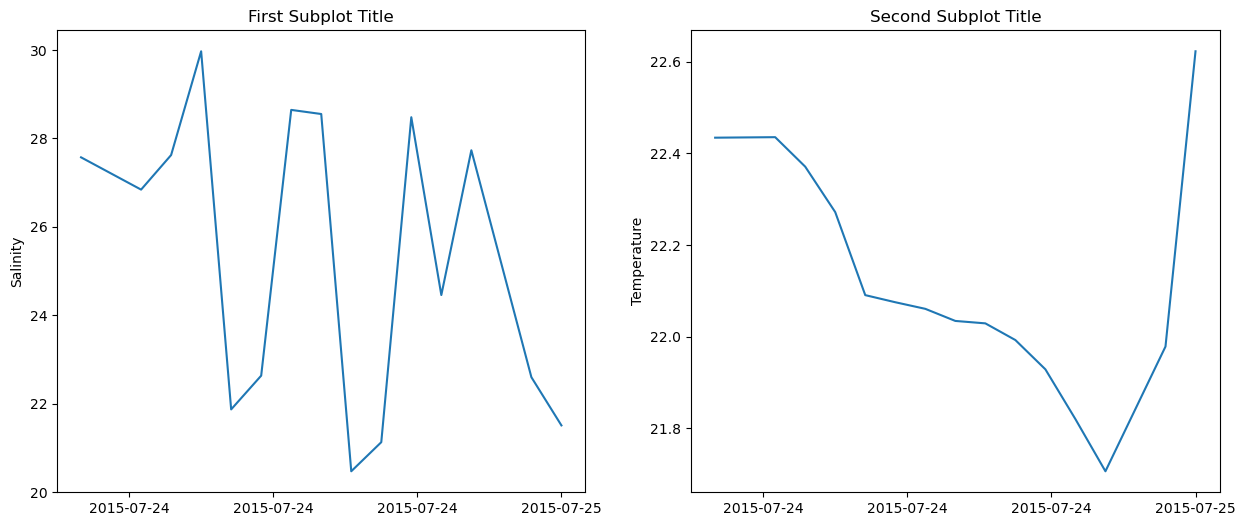

In [19]:
#we can also plot them on figure subplots
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

fig, axs = plt.subplots(1, 2, figsize=(15,6))
axs[0].plot(df['time'],df['salinity'])
axs[0].xaxis.set_major_locator(MaxNLocator(nbins=4)) # nbins=2 creates 3 ticks (start, middle, end)
axs[0].set_ylabel("Salinity")
axs[0].set_title('First Subplot Title')

# make the axis ticks pretty
axs[1].plot(df['time'],df['temp (C)'])
axs[1].xaxis.set_major_locator(MaxNLocator(nbins=4)) # nbins=2 creates 3 ticks (start, middle, end)
axs[1].set_ylabel("Temperature")
axs[1].set_title('Second Subplot Title')
